## 1. 目的と評価指標の整理（Kaggleサイトより）
*   目的：testデータの各idについて、目的変数 Heart Disease が Presence（心臓病あり） となる確率を予測し、提出する
*   タスク：二値分類（確率出力）
*   評価指標：ROC AUC（「心臓病あり（正例）」の人に、心臓病なし（負例）より 高い確率を付けて順位付けできているかを測る）
*   提出形式：id,Heart Disease（Heart Disease列には Presenceの予測確率 を入れる）
*   注意：データは実データではなく、合成データ（生成データ）

In [1]:
# Google Drive をマウント（最初に1回だけ）
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

# 参照フォルダ
base_path = "/content/drive/MyDrive/Kaggle研究会/playground-series-s6e2"

train = pd.read_csv(f"{base_path}/train.csv")
test = pd.read_csv(f"{base_path}/test.csv")
sample_sub = pd.read_csv(f"{base_path}/sample_submission.csv")

print(train.shape, test.shape, sample_sub.shape)
display(train.head())
display(sample_sub.head())

Mounted at /content/drive
(630000, 15) (270000, 14) (270000, 2)


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


,id,Heart Disease
0,630000,0
1,630001,0
2,630002,0
3,630003,0
4,630004,0


## 2. データ定義

In [4]:
# 日本語ラベル辞書
jp_labels = {
    "id": "識別ID",
    "Age": "年齢",
    "Sex": "性別",
    "Chest pain type": "胸痛のタイプ",
    "BP": "安静時血圧",
    "Cholesterol": "血清コレステロール値",
    "FBS over 120": "空腹時血糖値（120mg/dL超）",
    "EKG results": "心電図結果",
    "Max HR": "最大心拍数",
    "Exercise angina": "運動誘発性狭心症",
    "ST depression": "ST低下量",
    "Slope of ST": "STセグメントの傾き",
    "Number of vessels fluro": "造影で確認された血管数",
    "Thallium": "タリウム負荷検査結果",
    "Heart Disease": "心臓病の有無",
}

# 目的変数
target_candidates = ["Heart Disease", "Heart_Disease", "target"]
target = next((c for c in target_candidates if c in train.columns), None)
if target is None:
    raise ValueError(f"目的変数が見つかりません。train.columns を確認してください: {train.columns.tolist()}")

feature_cols = [c for c in train.columns if c in test.columns and c not in ["id"]]
print("target:", target)

# 日本語
def jp(col):
    return jp_labels.get(col, col)

# 日本語＋英語ラベル作成
def jp_with_en(col):
    jp_name = jp_labels.get(col, col)
    return f"{jp_name}（{col}）"

# 可視化・表出力用に「日本語列」DataFrameを作成
train_jp = train.rename(columns=jp_labels)
test_jp  = test.rename(columns=jp_labels)

target: Heart Disease


## 3. データ粒度確認

In [5]:
# 3.データ粒度確認
# 3-1) キー候補（id）の一意性
if "id" in train.columns and "id" in test.columns:
    print("train id unique:", train["id"].is_unique)
    print("test  id unique:", test["id"].is_unique)

# 3-2) 重複行の有無（全列一致）
print("train duplicated rows:", train.duplicated().sum())
print("test  duplicated rows:", test.duplicated().sum())

# 3-3) id重複がある場合、何が重複しているか（idでの重複）
if "id" in train.columns:
    dup_id = train["id"].duplicated().sum()
    print("train duplicated id:", dup_id)
    if dup_id > 0:
        display(train[train["id"].duplicated(keep=False)].sort_values("id").head(10))

# 3-4) 目的変数の型とクラス分布（件数＋割合）
print("target:", target)
print("target dtype:", train[target].dtype)
print(train[target].head())

# 件数
vc_count = train[target].value_counts(dropna=False)
print("\n[target] class counts")
display(vc_count.rename_axis("class").to_frame("count"))

# 割合（%）
vc_ratio = train[target].value_counts(normalize=True, dropna=False) * 100
print("\n[target] class ratios (%)")
display(vc_ratio.rename_axis("class").to_frame("ratio_%").round(2))

train id unique: True
test  id unique: True
train duplicated rows: 0
test  duplicated rows: 0
train duplicated id: 0
target: Heart Disease
target dtype: object
0    Presence
1     Absence
2     Absence
3     Absence
4    Presence
Name: Heart Disease, dtype: object

[target] class counts


,count
class,
Absence,347546
Presence,282454



[target] class ratios (%)


,ratio_%
class,
Absence,55.17
Presence,44.83


確認結果
*   1行の単位：id が一意
*   重複：重複行はない
*   目的変数：Heart Diseaseは文字（Presence / Absence）
*   クラス分布：Absence 約55%、Presence 約45%
*   学習・評価：行単位でROC AUC（二値分類）

## 4. 欠損・型確認

In [7]:
# 4.欠損・型確認
all_cols = feature_cols + [target]

# 4-1) 欠損率・型・ユニーク数を一括で出す
summary = pd.DataFrame({
    "列名": all_cols,
    "日本語訳": [jp(c) for c in all_cols],
    "役割": ["説明変数"] * len(feature_cols) + ["目的変数"],
    "dtype": [train[c].dtype for c in all_cols],
    "欠損率_train": [train[c].isna().mean() for c in all_cols],
    "欠損率_test":  [test[c].isna().mean() if c in test.columns else None for c in all_cols],
    "ユニーク数_train": [train[c].nunique(dropna=True) for c in all_cols],
})

display(summary.sort_values("役割"))

# 4-2) 数値/カテゴリのざっくり分類
num_cols = summary[summary["dtype"].apply(lambda x: np.issubdtype(x, np.number))]["列名"].tolist()
cat_cols = [c for c in feature_cols if c not in num_cols]

print("数値列:", len(num_cols), num_cols)
print("カテゴリ列:", len(cat_cols), cat_cols)

# 4-3) カテゴリ列の中身を軽く確認（上位だけ）
for c in cat_cols:
    print("\n[カテゴリ列]", c, ":", jp(c))
    display(train[c].value_counts(dropna=False).head(10))

,列名,日本語訳,役割,dtype,欠損率_train,欠損率_test,ユニーク数_train
13,Heart Disease,心臓病の有無,目的変数,object,0.0,NaN,2
0,Age,年齢,説明変数,int64,0.0,0.0,42
1,Sex,性別,説明変数,int64,0.0,0.0,2
2,Chest pain type,胸痛のタイプ,説明変数,int64,0.0,0.0,4
3,BP,安静時血圧,説明変数,int64,0.0,0.0,66
4,Cholesterol,血清コレステロール値,説明変数,int64,0.0,0.0,150
5,FBS over 120,空腹時血糖値（120mg/dL超）,説明変数,int64,0.0,0.0,2
6,EKG results,心電図結果,説明変数,int64,0.0,0.0,3
7,Max HR,最大心拍数,説明変数,int64,0.0,0.0,93
8,Exercise angina,運動誘発性狭心症,説明変数,int64,0.0,0.0,2


数値列: 13 ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
カテゴリ列: 0 []


確認結果
*   欠損：正解ラベル付きの学習データ／提出用の予測対象データとも欠損なし（欠損率0.0）
*   型：説明変数は 13列（id除く）で全て数値型（int/float）、idは識別子（int）
*   カテゴリ性：データの型は数値だが、値の種類が少ない列（例：Sex（性別）、Chest pain type（胸痛のタイプ）、EKG results（心電図結果）等）はカテゴリとして扱える
*   異常：データの型の不整合や欠損など、大きな品質問題は見られない
*   ⇒ 大きなデータ品質問題は見られない



## 5. データ可視化
*   目的変数割合
*   特徴分布
*   相関ヒートマップ

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

!pip -q install japanize-matplotlib
import japanize_matplotlib

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.family"] = "IPAexGothic"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 42.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


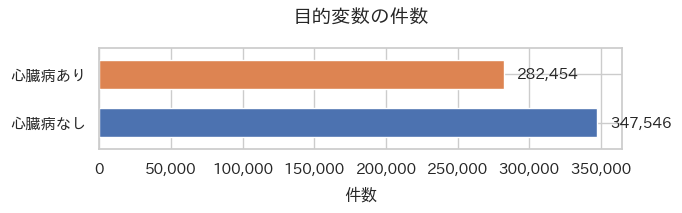

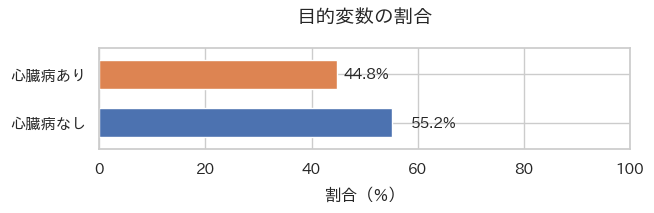

In [12]:
# 目的変数の割合（クラスの偏り）
import matplotlib.ticker as ticker
import numpy as np

# ラベル変換
label_map = {
    "Absence": "心臓病なし",
    "Presence": "心臓病あり"
}

colors = ["#4C72B0", "#DD8452"]

# 件数グラフ
vc = train[target].value_counts()
vc.index = vc.index.map(label_map)

fig, ax = plt.subplots(figsize=(7,2.3))

bars = ax.barh(
    vc.index,
    vc.values,
    color=colors,
    height=0.6  # ← 太くして間隔を自然に
)

ax.set_title("目的変数の件数", fontsize=14, pad=18)
ax.set_xlabel("件数", labelpad=8)

# 横軸を三桁カンマ表示
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# 上下の余白を追加
ax.margins(y=0.15)

for bar in bars:
    count = int(bar.get_width())
    ax.text(
        bar.get_width() + max(vc.values)*0.15,
        bar.get_y() + bar.get_height()/2,
        f"{count:,}",
        va='center',
        ha='right',
        fontsize=11
    )

plt.tight_layout()
plt.show()


# 割合グラフ
vc_ratio = train[target].value_counts(normalize=True) * 100
vc_ratio.index = vc_ratio.index.map(label_map)

fig, ax = plt.subplots(figsize=(6.7,2.3))

bars = ax.barh(
    vc_ratio.index,
    vc_ratio.values,
    color=colors,
    height=0.6
)

ax.set_title("目的変数の割合", fontsize=14, pad=18)
ax.set_xlabel("割合（%）", labelpad=8)
ax.set_xlim(0, 100)

ax.margins(y=0.15)

for bar in bars:
    ratio = bar.get_width()
    ax.text(
        bar.get_width() * 1.22,
        bar.get_y() + bar.get_height()/2,
        f"{ratio:.1f}%",
        va='center',
        ha='right',
        fontsize=11
    )

plt.tight_layout()
plt.show()

目的変数から言えること
*   目的変数は「心臓病なし」55.2%、「心臓病あり」44.8%であり、大きなクラス不均衡は見られない。
*   そのため、不均衡補正（class_weight等）は必須ではない。
*   ROC AUC評価との整合性も高く、モデル性能の解釈は妥当と考えられる。

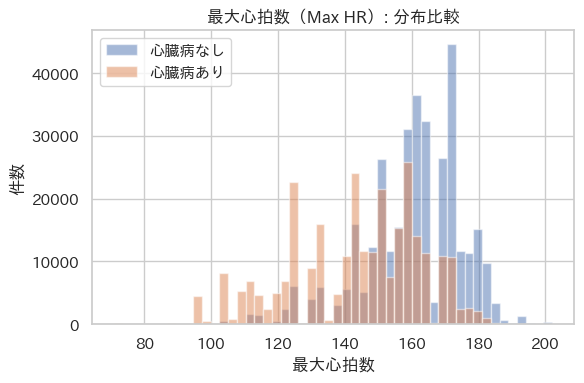

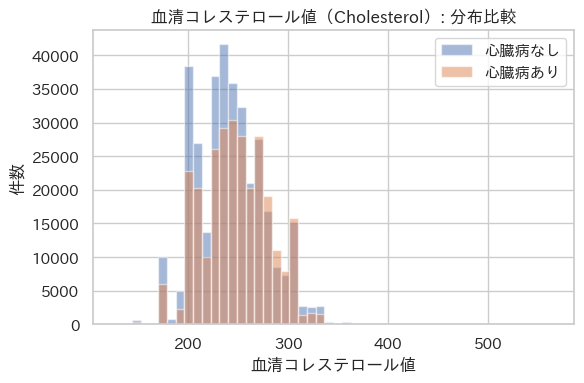

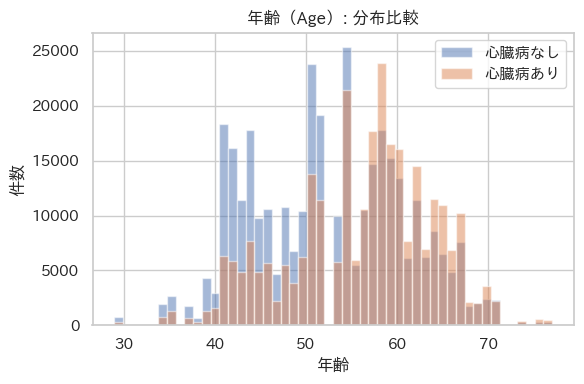

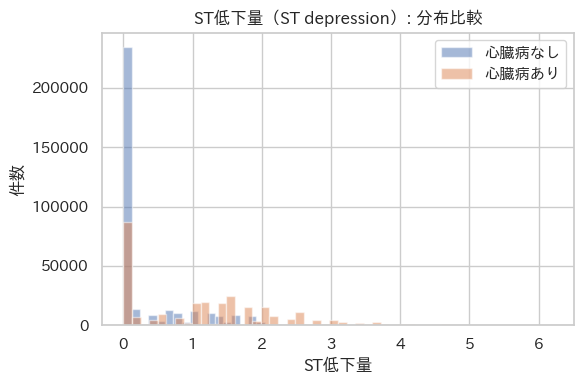

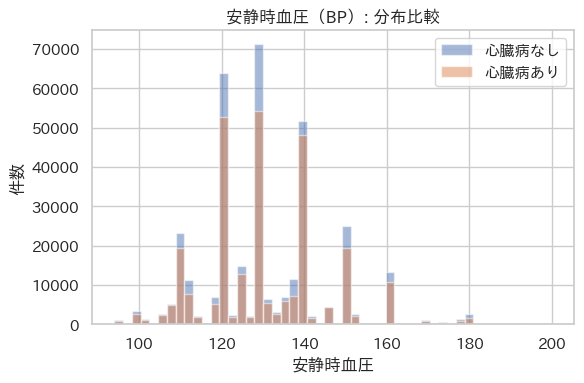

In [13]:
# 上位特徴量の分布（心臓病あり/なしで、どの特徴がどれくらい分離して見えるか）
top_cols = ["Max HR", "Cholesterol", "Age", "ST depression", "BP"]

presence_mask = train[target].eq("Presence")
absence_mask  = train[target].eq("Absence")

for col in top_cols:
    plt.figure(figsize=(6,4))

    plt.hist(
        train.loc[absence_mask, col].dropna(),
        bins=50,
        alpha=0.5,
        label="心臓病なし"
    )

    plt.hist(
        train.loc[presence_mask, col].dropna(),
        bins=50,
        alpha=0.5,
        label="心臓病あり"
    )

    plt.title(f"{jp(col)}（{col}）: 分布比較")
    plt.xlabel(jp(col))
    plt.ylabel("件数")
    plt.legend()
    plt.tight_layout()
    plt.show()

上位特徴量の分布から言えること

最大心拍数（Max HR）について
*   最大心拍数：運動負荷時に到達した最大の心拍数
*   解釈：心臓のポンプ機能や運動耐容能を反映/心機能が低いと十分に心拍数が上がらないことがある
*   今回のデータで強い理由：心臓病あり群は低めに分布/なし群は高めに分布 → 明確に分布がズレており分離している

血清コレステロール値（Cholesterol）について
*   血清コレステロール値：血液中のコレステロール濃度
*   解釈：高値は動脈硬化のリスク因子/血管狭窄や心疾患につながる可能性
*   今回のデータで強い理由：やや高値側にシフトしている/ただし分布の重なりは大きい → 単独よりも他特徴との組み合わせで効く

年齢（Age）について
*   解釈：加齢により動脈硬化・心血管リスク上昇/基本的なリスク因子
*   今回のデータで強い理由：心臓病あり群が高齢側にシフト → 医学的直感と一致し、安定した分離がある

ST低下量について
*   ST：心電図（ECG）の波形の一部。S波の終わり〜T波の始まりの区間（ST部分）
*   意味：心臓の筋肉が収縮している時間帯（心室が活動している局面）を表す
*   ST depression（ST低下量）：ST部分が基準線よりどれだけ下がっているかの量
*   解釈：値が大きいほど、心筋虚血（心臓の血流不足）の可能性が高く、心臓病リスクが高い傾向
*   今回のデータで強い理由：心臓病あり/なしで分布がズレやすく、分類に効きやすい指標

安静時血圧（BP）について
*   解釈：高血圧は心疾患の主要リスク因子/血管への慢性的負荷を示す
*   今回のデータで強い理由：あり群でやや高値側/ただし重なりは大きい → 補助的な説明力

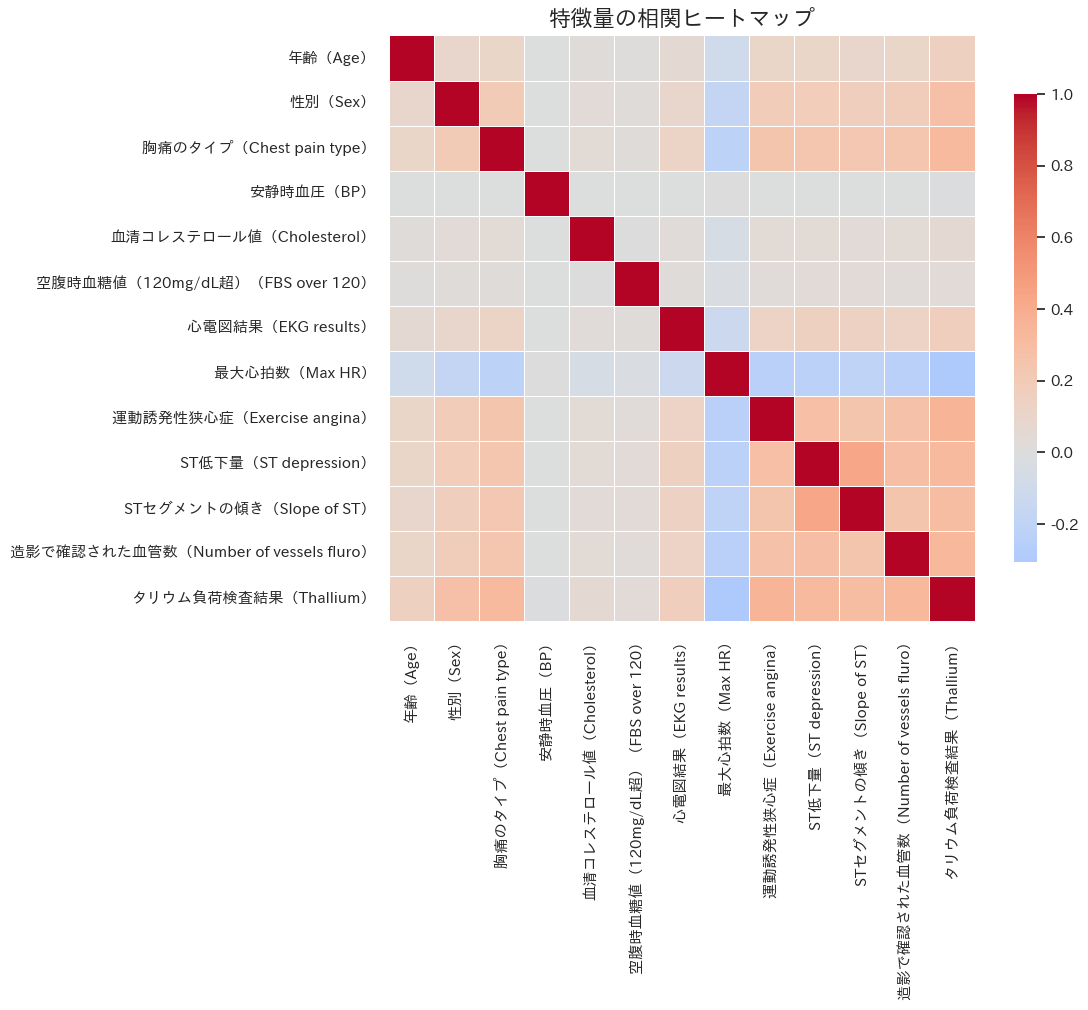

In [14]:
# 相関ヒートマップ（データ構造理解）
# 相関計算
corr = train[feature_cols].corr(numeric_only=True)

# 列名を日本語（英語）に変換
corr_jp = corr.copy()
corr_jp.columns = [jp_with_en(c) for c in corr.columns]
corr_jp.index   = [jp_with_en(c) for c in corr.index]

# 描画
plt.figure(figsize=(12,10))

sns.heatmap(
    corr_jp,
    cmap="coolwarm",        # 発散型カラー（青〜白〜赤）
    center=0,               # 0を中央に
    annot=False,            # 数値を出すならTrue
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("特徴量の相関ヒートマップ", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

相関ヒートマップから言えること

* 全体として、強い相関（|corr|が大きい組み合わせ）は多くなく、特徴量同士は概ね独立している。
* 一方で、**運動負荷や虚血に関係する特徴量群**（例：運動誘発性狭心症、ST低下量、STセグメントの傾き、造影で確認された血管数、タリウム負荷検査結果など）では、**正の相関がまとまって見られる**。

  * これは「同じ現象（虚血・血管狭窄）を別の角度から測っている変数が複数ある」ことを示唆する。
* **最大心拍数（Max HR）は、上記の虚血関連の変数と負の相関が見られる**。

  * 最大心拍数が高いほど、虚血のサイン（ST低下など）が小さくなる傾向がある、という関係として解釈できる。
* **安静時血圧（BP）や血清コレステロール（Cholesterol）は、他の特徴量との相関が相対的に弱い**。

  * これらは単独で強く連動するというより、他の要因と組み合わせてリスクを説明する補助的な特徴になりやすい。

（補足）相関は「2変数の直線的な関係」を表すため、相関が弱くてもモデル（木モデル）では非線形・閾値・組み合わせで効く可能性がある。


## 6. 前処理方針

* 欠損はないため、**欠損補完は行わない**
* 目的変数 **Heart Disease** は
  **Presence（心臓病あり）=1 / Absence（心臓病なし）=0** に変換する
* **id は識別子のため特徴量から除外**する（リーク防止・汎化性のため）
* 特徴量は基本的に数値型だが、**ユニーク数が少ない列はカテゴリ的性質を持つ可能性がある**
* まずは **数値のままベースライン学習**を行い、性能を確認する
* 改善案として、**ユニーク数が少ない列をカテゴリ列として抽出し、LightGBMの categorical_featureとして指定**して性能変化を確認する

  * ただしカテゴリ指定の有無で性能差が小さい場合もあるため、採用は実験結果に基づいて判断する
* 木モデル（LightGBM）を前提とするため、**スケーリングは行わない**
* ⇒ **最小限の前処理で学習を開始し、必要に応じてカテゴリ指定や正則化・学習率調整などのモデル側の改善を追加**する


## 7. モデル確認

In [15]:
# 7-1) 学習データ作成（目的変数変換・id除外）
# 目的変数を 0/1 に変換
y = train[target].map({"Presence": 1, "Absence": 0})
if y.isna().any():
    raise ValueError("目的変数に Presence/Absence 以外が含まれています。value_countsで確認してください。")

# 特徴量：id と target を除外
drop_cols = ["id", target]
X = train.drop(columns=[c for c in drop_cols if c in train.columns])
X_test = test.drop(columns=[c for c in ["id"] if c in test.columns])

print("X shape:", X.shape, "X_test shape:", X_test.shape, "y shape:", y.shape)

# --- カテゴリ列の抽出（ユニーク数が少ない列） ---
cat_cols = []
for c in X.columns:
    if X[c].nunique(dropna=False) <= 10:  # 閾値は必要なら調整
        cat_cols.append(c)

print("categorical cols:", cat_cols)

# --- category型に変換 ---
for c in cat_cols:
    X[c] = X[c].astype("category")
    X_test[c] = X_test[c].astype("category")

X shape: (630000, 13) X_test shape: (270000, 13) y shape: (630000,)
categorical cols: ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


In [16]:
# 7-2) LightGBMでベースラインCV（ROC AUC）
# LightGBM がなければインストール（1回だけ）
try:
    import lightgbm as lgb
except ImportError:
    !pip -q install lightgbm
    import lightgbm as lgb

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

params = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.05,
    "n_estimators": 2000,
    "num_leaves": 31,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "n_jobs": -1,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof = np.zeros(len(X))
test_pred = np.zeros(len(X_test))

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric="auc",
        categorical_feature=cat_cols,   # ←追加
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )

    oof[va_idx] = model.predict_proba(X_va)[:, 1]
    test_pred += model.predict_proba(X_test)[:, 1] / skf.n_splits

    fold_auc = roc_auc_score(y_va, oof[va_idx])
    print(f"fold{fold} AUC: {fold_auc:.5f}")

cv_auc = roc_auc_score(y, oof)
print("CV AUC:", round(cv_auc, 5))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.104615 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 426
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 13
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448339 -> initscore=-0.207383
[LightGBM] [Info] Start training from score -0.207383
fold1 AUC: 0.95559
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.091957 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM]

In [19]:
# ===== v4：正則化パラメータ =====
params_reg = params.copy()

params_reg.update({
    "num_leaves": 25,
    "min_child_samples": 50,
    "reg_lambda": 1.0
})

In [17]:
# ===== v5：learning_rate調整（正則化なし） =====
params_lr = params.copy()
params_lr.update({
    "learning_rate": 0.03,
    "n_estimators": 5000,   # early stoppingがあるので大きめにしてOK
})

In [20]:
# ===== v6：正則化 + learning_rate調整 =====
params_v6 = params_reg.copy()
params_v6.update({
    "learning_rate": 0.03,
    "n_estimators": 5000
})

In [21]:
# 7-3) 改善：seed平均（LightGBMは同じ）
seeds = [42, 2024, 777, 13, 999]

oof_seed = np.zeros(len(X))
test_pred_seed = np.zeros(len(X_test))

for seed in seeds:
    print(f"\n===== seed: {seed} =====")

    params_seed = params_v6.copy()
    params_seed["random_state"] = seed

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    oof_tmp = np.zeros(len(X))
    test_tmp = np.zeros(len(X_test))

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        model = lgb.LGBMClassifier(**params_seed)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="auc",
            categorical_feature=cat_cols,  # さきほど入れた場合はそのまま
            callbacks=[lgb.early_stopping(100, verbose=False)]
        )

        oof_tmp[va_idx] = model.predict_proba(X_va)[:, 1]
        test_tmp += model.predict_proba(X_test)[:, 1] / skf.n_splits

    seed_auc = roc_auc_score(y, oof_tmp)
    print(f"seed {seed} CV AUC: {seed_auc:.5f}")

    oof_seed += oof_tmp / len(seeds)
    test_pred_seed += test_tmp / len(seeds)

# 最終AUC（seed平均）
cv_auc_seed = roc_auc_score(y, oof_seed)
print("\nSeed平均 CV AUC:", round(cv_auc_seed, 5))


===== seed: 42 =====
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.092882 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 426
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 13
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448339 -> initscore=-0.207383
[LightGBM] [Info] Start training from score -0.207383
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.097620 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if 

7-1. ベースライン
*   目的：前処理方針（欠損なし／id除外／目的変数0/1変換／カテゴリ的列は数値のまま）で、まずはベースライン性能を確認する
*   モデル：LightGBM（木モデル）
*   検証：Stratified K-Fold（5分割）
*   評価指標：ROC AUC
*   結果：
    *   fold1 AUC = 0.95559
    *   fold2 AUC = 0.95458
    *   fold3 AUC = 0.95537
    *   fold4 AUC = 0.95490
    *   fold5 AUC = 0.95575
    *   CV AUC = 0.95524

7-2. 改善（カテゴリ列をLightGBMのcategorical_featureとして指定）
*   目的：ユニーク数が少ない列をカテゴリ型として扱い、性能変化を確認する。
*   結果：
    *   fold1 AUC = 0.95559
    *   fold2 AUC = 0.95458
    *   fold3 AUC = 0.95542
    *   fold4 AUC = 0.95493
    *   fold5 AUC = 0.95572
    *   CV AUC = 0.95525
*   考察：ベースラインとほぼ同等（+0.00001）。大きな改善は見られない。

7-3. 改善（Seed平均：LightGBM×3）
*   目的：同一モデル（LightGBM）でseedを変えて学習し、予測確率を平均して汎化性能の安定化を狙う
*   設定：
    *   seeds = [42, 2024, 777]
    *   CV = StratifiedKFold 5分割（seedごとにshuffle）
*   結果：
    *   seed 42   CV AUC = 0.95525
    *   seed 2024 CV AUC = 0.95527
    *   seed 777  CV AUC = 0.95524
    *   Seed平均  CV AUC = 0.95535

7-4. 改善（Seed平均：LightGBM×5）
*   目的：同一モデル（LightGBM）でseedを3から5に変えて学習し、予測確率を平均して汎化性能の安定化を狙う
*   設定：
    *   seeds = [42, 2024, 777, 13, 999]
    *   CV = StratifiedKFold 5分割（seedごとにshuffle）
*   結果：
    *   seed 42   CV AUC = 0.95527
    *   seed 2024 CV AUC = 0.95524
    *   seed 777  CV AUC = 0.95524
    *   seed 13   CV AUC = 0.95530
    *   seed 999  CV AUC = 0.95530
    *   Seed平均  CV AUC = 0.95538

7-5. 改善（正則化）
*   目的：モデルの複雑さを抑える（過学習を抑制する）設定に変更し、CVおよびLBの安定性・汎化性能が改善するかを確認する。（num_leavesを小さくして分割の自由度を下げ、min_child_samplesを増やして細かい分割を抑え、reg_lambdaでL2正則化を入れる）
*   設定：
    *   params差分：num_leaves=25, min_child_samples=50, reg_lambda=1.0
    *   seeds = [42, 2024, 777, 13, 999]
    *   CV = StratifiedKFold 5分割（seedごとにshuffle）
*   結果：
    *   seed 42   CV AUC = 0.95529
    *   seed 2024 CV AUC = 0.95532
    *   seed 777  CV AUC = 0.95529
    *   seed 13   CV AUC = 0.95531
    *   seed 999  CV AUC = 0.95536
    *   Seed平均  CV AUC = 0.95542
    
7-6. 改善（learning_rate調整）
*   目的：学習率を下げて（1本あたりの更新量を小さくして）より丁寧に学習させ、早期終了と組み合わせたときの汎化性能が改善するかを確認する。（learning_rate↓に伴いn_estimators↑として、early stoppingで最適な木数に自動調整させる）
*   設定：
    *   params差分：learning_rate=0.03, n_estimators=5000
    *   seeds = [42, 2024, 777, 13, 999]
    *   CV = StratifiedKFold 5分割（seedごとにshuffle）
*   結果：
    *   seed 42   CV AUC = 0.95527
    *   seed 2024 CV AUC = 0.95529
    *   seed 777  CV AUC = 0.95526
    *   seed 13   CV AUC = 0.95526
    *   seed 999  CV AUC = 0.95532
    *   Seed平均  CV AUC = 0.95539

7-7. 改善（正則化 + learning_rate調整）
*   目的：「過学習抑制（正則化）」と「丁寧な学習（learning_rate↓）」を同時に適用し、CVとLBの両方で安定して高性能になるか（相乗効果が出るか）を確認する。
*   設定：
    *   params差分：num_leaves=25, min_child_samples=50, reg_lambda=1.0, learning_rate=0.03, n_estimators=5000
    *   seeds = [42, 2024, 777, 13, 999]
    *   CV = StratifiedKFold 5分割（seedごとにshuffle）
*   結果：
    *   seed 42   CV AUC = 0.95531
    *   seed 2024 CV AUC = 0.95534
    *   seed 777  CV AUC = 0.95531
    *   seed 13   CV AUC = 0.95531
    *   seed 999  CV AUC = 0.95537
    *   Seed平均  CV AUC = 0.95542

*   ※補足：Found whitespace in feature_names は「列名に空白があるのでLightGBM が_に置換した」という警告で、学習自体には致命的な問題はありません。

## 8. 妥当性確認

In [11]:
# 8-1) 重要度の確認（妥当性チェック用）
import pandas as pd

imp = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

# 日本語名も付けたい場合（辞書がある前提）
imp["feature_jp"] = imp["feature"].map(lambda c: jp_labels.get(c, c))

display(imp.head(15))

,feature,importance,feature_jp
7,Max HR,4070,最大心拍数
4,Cholesterol,3206,血清コレステロール値
0,Age,2769,年齢
9,ST depression,2217,ST低下量
3,BP,2099,安静時血圧
11,Number of vessels fluro,947,造影で確認された血管数
2,Chest pain type,872,胸痛のタイプ
10,Slope of ST,631,STセグメントの傾き
1,Sex,629,性別
8,Exercise angina,614,運動誘発性狭心症


8-1. 重要度の確認（妥当性チェック用）
*   データリーク/手続き面：
    *   id は除外（識別子のため）
    *   目的変数は Presence=1 / Absence=0 に変換（文字列→数値）
    *   欠損がないため欠損補完なし
*   予測確率の妥当性：
    *   CV AUC=0.95524 と高く、ベースラインとして成立している
    *   fold間のばらつきは小さい（0.95458〜0.95575で安定）
*   特徴量の妥当性（軽い確認）：
    *   重要度上位：
        1. Max HR（最大心拍数）
        2. Cholesterol（血清コレステロール値）
        3. Age（年齢）
        4. ST depression（ST低下量）
        5. BP（安静時血圧）
    *   心臓病リスクと関連しやすい要素が上位に出ており、直感と大きく矛盾しない
*   次の改善候補（時間があれば）：
    *   LightGBMのパラメータ微調整（例：num_leaves / min_child_samples / reg_lambda、学習率と木の本数）
    *   “カテゴリ的な列”をカテゴリ扱いにする（またはone-hot）／別モデル（LogisticRegression等）で比較

8-2. モデル可視化・解釈
*   ROC曲線
*   SHAP

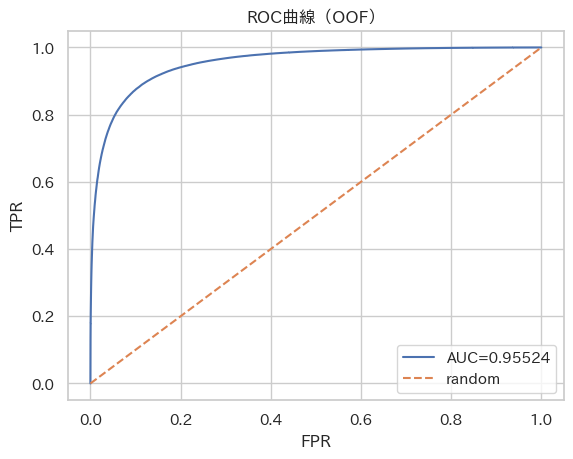

In [16]:
# ROC曲線（性能確認：AUCが“どういう形で”出ているか）
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y, oof)
auc = roc_auc_score(y, oof)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC={auc:.5f}")
plt.plot([0,1], [0,1], linestyle="--", label="random")
plt.title("ROC曲線（OOF）")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

ROC曲線から言えること

* ROC曲線は、横軸に偽陽性率（FPR）、縦軸に真陽性率（TPR）をとり、**モデルの識別性能を閾値ごとに評価したもの**である。
* 本モデルのROC曲線は、ランダム分類（対角線）より大きく左上側に位置しており、**十分な識別能力を持つことが確認できる**。
* AUCは **0.955** と非常に高く、

  * 0.5（ランダム）を大きく上回り、
  * 0.9以上であることから「高精度モデル」と評価できる。
* 曲線が急激に立ち上がっていることから、
  **偽陽性をあまり増やさずに高い真陽性率を確保できている**ことが分かる。
* 特にFPRが0.1未満の範囲でもTPRが高く、
  **実務上も使いやすい性能水準である**と考えられる。

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


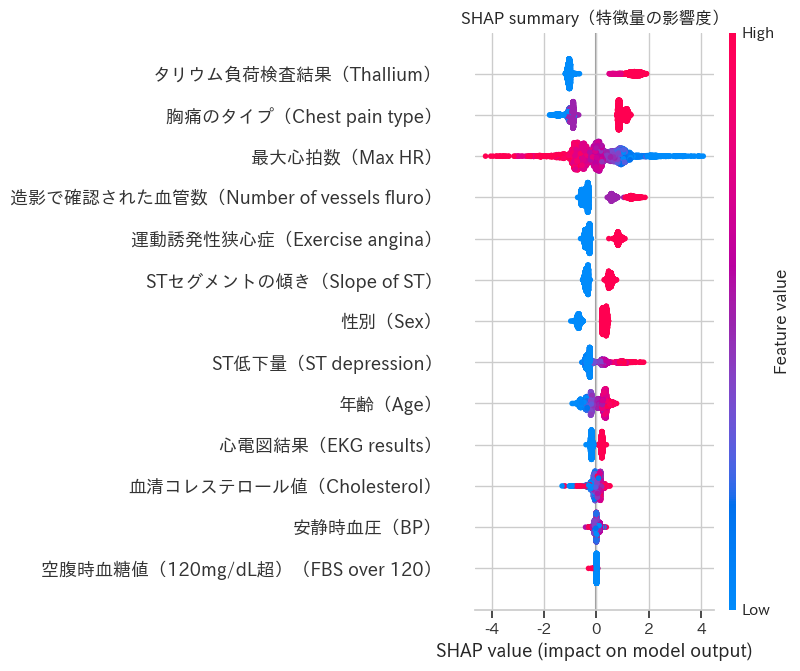

In [17]:
# SHAP（モデルの意思確認：重要な特徴は何か（全体）/値が大きいとリスクが上がるのか下がるのか（方向性）/“医療的に変じゃないか”の精査ができる
# shap がなければインストール
try:
    import shap
except ImportError:
    !pip -q install shap
    import shap

# 学習済み model を使う（直近foldの model でもOK）
X_small = X.sample(5000, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_small)

# 可視化用に列名だけ日本語へ（学習データは触らない）
X_small_jp = X_small.copy()
X_small_jp.columns = [jp_with_en(c) for c in X_small_jp.columns]

# SHAP summary（重要度＋方向性）
shap.summary_plot(shap_values, X_small_jp, show=False)
plt.title("SHAP summary（特徴量の影響度）")
plt.show()

**① 重要度（上にあるほど影響が大きい）**

  * 影響が大きい特徴量（上位）

    * タリウム負荷検査結果（Thallium）
    * 胸痛のタイプ（Chest pain type）
    * 最大心拍数（Max HR）
    * 造影で確認された血管数（Number of vessels fluro）
    * 運動誘発性狭心症（Exercise angina）
    * STセグメント関連（ST depression / Slope of ST）
  * 解釈

    * 虚血・負荷検査系の指標が上位に集中
    * 医学的にも整合的で、モデルは「心筋虚血を直接反映する変数」を強く使っていると考えられる

**② 色の意味（方向性）**

  * 赤：特徴量の値が高い
  * 青：特徴量の値が低い
  * 右（＋SHAP）：心臓病あり方向（Presence側）へ寄与
  * 左（−SHAP）：心臓病なし方向（Absence側）へ寄与

**③ 各特徴の解釈（代表例）**

  * タリウム負荷検査（Thallium）

    * 高値（赤）が右側に集中
    * ⇒ 異常所見ほど「心臓病あり」方向に強く寄与
  * 最大心拍数（Max HR）

    * 低値（青）が右側に多い
    * ⇒ 最大心拍数が低いほど「心臓病あり」方向に寄与
  * ST低下量（ST depression）

    * 高値（赤）が右側に多い
    * ⇒ ST低下が大きいほど「心臓病あり」方向に寄与
  * 造影で確認された血管数（Number of vessels fluro）

    * 高値が右側に多い
    * ⇒ 狭窄・異常が多いほど「心臓病あり」方向に寄与

**④ 年齢・コレステロール・血圧の位置づけ**

  * 年齢（Age）、血清コレステロール（Cholesterol）、安静時血圧（BP）

    * SHAP分布が中央寄りで、影響は相対的に小さめ
    * ⇒ 単独で決めるというより、他特徴との組み合わせで効く可能性が高い


## 9. 結論（解釈も反映した最終版）

9-0. 到達点（データ品質と実行可能性）

* 現時点では、**データ品質（欠損なし・重複なし）と前処理方針に大きな問題は見られず、提出用予測を作成できる状態にある。**

9-1. 最終結果（採用モデル）

* 最終採用：**LightGBM（5-fold CV）**
* 工夫：**カテゴリ列の指定（categorical_feature）＋ seed平均（5 seeds）＋ 正則化**
* 最終スコア：

  * **CV AUC：0.95542**
  * **LB：0.95344（1425位）**

9-2. 妥当性確認（モデルの説明と整合性）

* **性能の安定性**：fold間のばらつきが小さく、CV AUCも高水準で安定しているため、ベースラインとして十分成立している。
* **重要特徴の整合性**：重要度上位には、心疾患リスクと関連しやすい特徴が並び、医学的直感と大きく矛盾しない。

  * 例：**Max HR、ST depression、Age、Cholesterol、BP** など
* **分布からの示唆（代表例）**：

  * **Max HR**：心臓病あり群で低め、なし群で高めに分布し、比較的分離が明確
  * **ST depression**：値が大きいほど虚血傾向を示し、あり/なしで分布がずれやすく分類に寄与
  * **Age**：あり群が高齢側にシフトし、安定したリスク因子として効いている
  * **Cholesterol / BP**：重なりは大きく、単独よりも他特徴との組み合わせで補助的に効く傾向
* **相関構造の理解**：全体として強い相関は多くなく概ね独立だが、虚血・負荷検査系の特徴量群（ST関連、運動誘発性狭心症、血管数、タリウムなど）ではまとまりが見られ、同一現象を別角度から測っていることが示唆される。
* **ROC / SHAPの確認**：ROCは左上に張り付きAUCは高水準で、SHAPでも虚血・負荷検査系の特徴が上位に現れ、方向性も概ね整合的だった。

9-3. 施策ごとの学び（何が効いたか）

* **カテゴリ指定（categorical_feature）**：影響は小（CVはほぼ同等）
* **Seed平均（3→5）**：微増だが予測が安定
* **正則化**：CV/LBともに改善し最も効果があった
* **learning_rate調整**：正則化単独以上の改善は確認できず（CV/LB同等）

9-4. 最終版の設定（採用）

* params差分：num_leaves=25, min_child_samples=50, reg_lambda=1.0
* seeds：[42, 2024, 777, 13, 999]


In [22]:
submission = sample_sub.copy()
submission[target] = test_pred_seed
submission.to_csv("submission_v6_seed5_cat_reg_lr003.csv", index=False)

## 10. 提出履歴（記録用）
* v1 baseline：CV 0.95524 / LB 0.95281（categorical_featureなし、seed平均なし）
* v2 seed平均(3) + categorical：CV 0.95535 / LB 0.95338
* v3 seed平均(5) + categorical：CV 0.95538 / LB 0.95539（1593位）
* v4 seed平均(5) + categorical + 正則化：**CV 0.95542 / LB 0.95344（1425位）** ←最終採用
* v5 seed平均(5) + learning_rate：CV 0.95539（不採用）
* v6 seed平均(5) + 正則化 + learning_rate：CV 0.95542 / LB v4と同等（不採用）

## **Appendix**
---
**A1. 上位特徴量の分布と医学的解釈**

**1) 最大心拍数（Max HR）**

**定義**
運動負荷時に到達した最大心拍数。

**医学的解釈**

* 心臓のポンプ機能や運動耐容能を反映
* 心機能が低い場合、十分に心拍数が上がらないことがある

**本データでの観察結果**

* 心臓病あり群は低めに分布
* 心臓病なし群は高めに分布
  → 分布のズレが明確で、分類に強く寄与
---
**2) 血清コレステロール値（Cholesterol）**

**定義**
血液中のコレステロール濃度。

**医学的解釈**

* 高値は動脈硬化のリスク因子
* 血管狭窄や心疾患につながる可能性

**本データでの観察結果**

* あり群でやや高値側にシフト
* ただし分布の重なりは大きい
  → 単独よりも他特徴との組み合わせで効果を発揮
---
**3) 年齢（Age）**

**医学的解釈**

* 加齢により動脈硬化・心血管リスクが上昇
* 基本的かつ安定したリスク因子

**本データでの観察結果**

* 心臓病あり群が高齢側にシフト
  → 医学的直感と一致し、安定した分離が確認できる
---
**4) ST低下量（ST depression）**

**定義**
心電図（ECG）のST部分が基準線よりどれだけ下がっているかの量。

**医学的解釈**

* 値が大きいほど心筋虚血（血流不足）の可能性が高い
* 心疾患リスクと関連

**本データでの観察結果**

* 心臓病あり群で高値側に分布
  → 分布がズレやすく、分類に寄与しやすい指標
---
**5) 安静時血圧（BP）**

**医学的解釈**

* 高血圧は心疾患の主要リスク因子
* 血管への慢性的負荷を示す

**本データでの観察結果**

* あり群でやや高値側
* ただし分布の重なりは大きい
  → 補助的な説明力を持つ特徴
---
**A2. 相関ヒートマップからの示唆**

全体傾向

* 強い相関（|corr|が大きい組み合わせ）は多くない
  → 特徴量同士は概ね独立している

虚血・負荷検査系のまとまり

* ST低下量
* STセグメントの傾き
* 運動誘発性狭心症
* 造影で確認された血管数
* タリウム負荷検査結果
* ⇒ これらは正の相関がまとまって見られる。

**解釈**

同じ現象（虚血・血管狭窄）を、異なる検査・指標で測定している可能性を示唆する。

最大心拍数との関係

* Max HR は虚血関連指標と負の相関を示す
  → 最大心拍数が高いほど虚血サインが小さいBP・Cholesterolの位置づけ

* 他特徴との相関は比較的弱い
  → 単独で強く連動するというより、他特徴との組み合わせで効く傾向
* ※ 相関は「直線的な関係」のみを表す。
木モデルでは非線形・閾値・組み合わせ効果も捉えられるため、相関が弱くても重要である可能性がある。
---
**A3. ROC曲線の解釈**

* ROC曲線は左上方向に位置し、ランダム分類（対角線）を大きく上回る
* AUC = 約0.955 と高水準
* FPRが低い領域でもTPRが高い
  → 偽陽性を大きく増やさずに真陽性を高確率で検出できる
* ⇒ 実務的にも十分な識別能力を持つモデルと評価できる。
---
**A4. SHAPによるモデル解釈**

**重要度上位特徴**

* Thallium（タリウム負荷検査結果）
* Chest pain type（胸痛タイプ）
* Max HR（最大心拍数）
* Number of vessels fluro（造影血管数）
* Exercise angina（運動誘発性狭心症）
* ST関連指標
* ⇒ 虚血・負荷検査系の特徴が上位に集中している。
---
**SHAP値の方向性**

* 赤：値が高い
* 青：値が低い
* 右側：心臓病あり方向（Presence）
* 左側：心臓病なし方向（Absence）

**代表例**

* **Thallium**：異常所見（高値）がPresence側に強く寄与
* **Max HR**：低値がPresence側に寄与
* **ST depression**：高値がPresence側に寄与
* **血管数**：多いほどPresence側に寄与

**年齢・コレステロール・血圧**

* SHAP分布は中央寄り
  → 単独決定因子というより、補助的特徴として機能
